Part-I: Naive Bayes Classifier Assignment

Task 1: Theory Questions 
 
1. What is the core assumption of Naive Bayes? 

Ans 1.The core assumption of Naive Bayes is that all features are conditionally independent of each other given the class label. This means the presence or absence of one feature does not affect the others, which simplifies computation significantly.

2. Differentiate between GaussianNB, MultinomialNB, and BernoulliNB. 

Ans 2.GaussianNB: Assumes features follow a normal (Gaussian) distribution; suitable for continuous data.

MultinomialNB: Designed for count data (e.g., word frequencies); used in text classification and document categorization.

BernoulliNB: Works with binary/boolean features (e.g., word present or not); also used in text classification but for binary representations.

3. Why is Naive Bayes considered suitable for high-dimensional data?

Ans 3.Naive Bayes is suitable for high-dimensional data because:

It assumes feature independence, reducing model complexity.

It is computationally efficient, requiring less training time even with many features.

It performs well in text classification tasks, where data is often sparse and high-dimensional.



Task 2: Spam Detection using MultinomialNB 

● Load a text dataset (e.g., SMS Spam Collection or any public text 
dataset). 

● Preprocess using CountVectorizer or TfidfVectorizer.

● Train a MultinomialNB classifier. 

● Evaluate: 

○ Accuracy 
○ Precision 
○ Recall 
○ Confusion Matrix 

Accuracy: 0.979372197309417
Precision: 0.9150326797385621
Recall: 0.9333333333333333

Confusion Matrix:
 [[952  13]
 [ 10 140]]


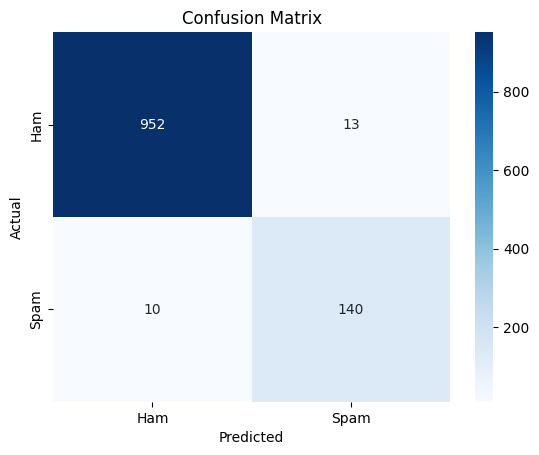

In [1]:
#Task 2: Spam Detection using MultinomialNB

# Step 1: Importing Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Loading the Dataset
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]  # Keeping only necessary columns
df.columns = ['label', 'message']

# Step 3: Preprocessing
# Converting labels to binary
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Step 4: Vectorization
vectorizer = CountVectorizer()  # TfidfVectorizer can also be use
X = vectorizer.fit_transform(df['message'])
y = df['label']

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the MultinomialNB Model
model = MultinomialNB()
model.fit(X_train, y_train)

# Step 7: Make Predictions
y_pred = model.predict(X_test)

# Step 8: Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("\nConfusion Matrix:\n", cm)

# Step 9: Visualize Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Task 3: GaussianNB with Iris or Wine Dataset

● Train a GaussianNB classifier on a numeric dataset.

● Split data into train/test sets. 

● Evaluate model performance. 

● Compare with Logistic Regression or Decision Tree briefly.

In [ ]:
# Task 3: GaussianNB with Iris or Wine Dataset

# Step 1: Importing Libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 2: Loading Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Training GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

# Step 5: Evaluating GaussianNB
print("🔹 GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("Classification Report:\n", classification_report(y_test, y_pred_gnb))

# Step 6: Comparing with Logistic Regression and Decision Tree
# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("🔹 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("🔹 Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Step 7: Brief Comparison
print("""
GaussianNB is fast for normal data, 
Logistic Regression offers interpretability,
 while Decision Tree fits well but may overfit.
""")


Part-II: Decision Trees Assignment

Task 4: Conceptual Questions 
 
1. What is entropy and information gain? 

Ans 1.Entropy measures the impurity or uncertainty in data.

Information Gain is the reduction in that uncertainty after splitting on a feature.

2. Explain the difference between Gini Index and Entropy.

Ans 2.Both measure data impurity in decision trees, but differ slightly:

Gini Index is easier to compute and tends to favor larger partitions; it measures the probability of incorrect classification.

Entropy is based on information theory and accounts for the level of disorder; it may lead to more balanced splits.

3. How can a decision tree overfit? How can this be avoided? 

Ans 3.A decision tree overfits by becoming too deep or complex, learning noise instead of general patterns.

This can be avoided by pruning, setting a maximum depth, using minimum sample splits, or applying ensemble methods like Random Forest.



Task 5: Decision Tree on Titanic Dataset

● Load Titanic dataset (or use a similar dataset). 

● Preprocess (handle missing values, encode categorical variables). 

● Train a DecisionTreeClassifier. 

● Visualize the decision tree using plot_tree. 

● Evaluate the model using accuracy and confusion matrix. 

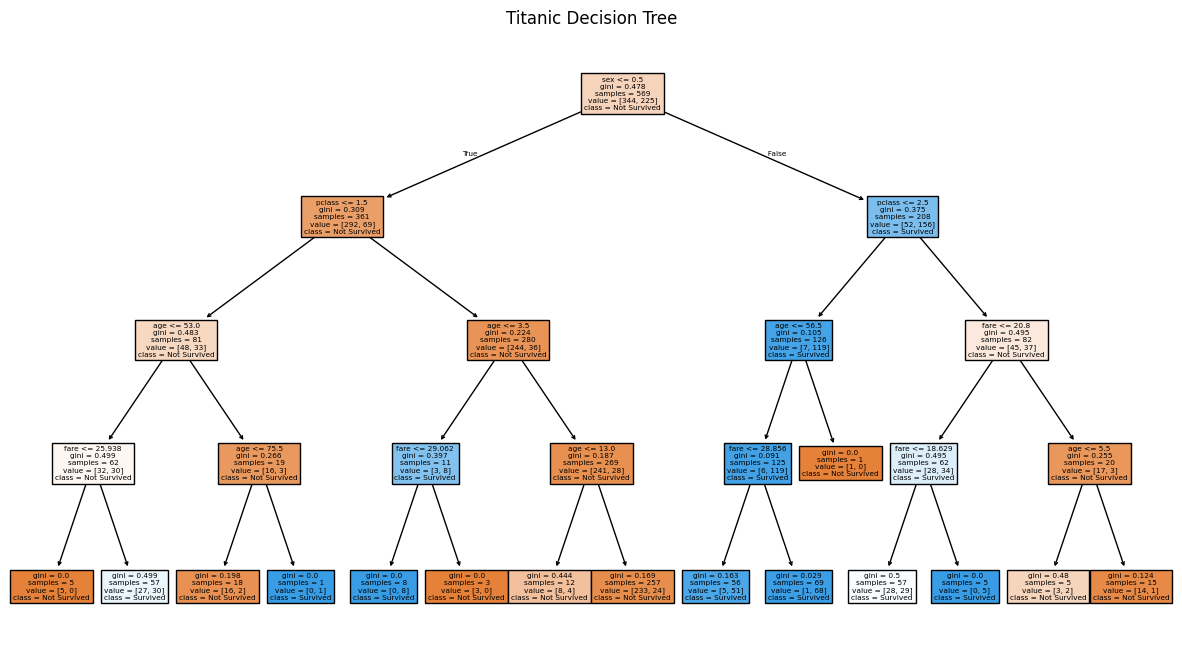

Accuracy: 0.7132867132867133
Confusion Matrix:
 [[60 20]
 [21 42]]


In [2]:
# Task 5: Decision Tree on Titanic Dataset

# Step 1: Importing Libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Step 2: Loading Titanic Dataset
df = sns.load_dataset("titanic")
df.head()

# Step 3: Preprocessing
# Dropping rows with missing target
df = df.dropna(subset=["age", "embarked", "sex", "fare", "survived"])

# Encoding categorical variables
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["embarked"] = df["embarked"].map({"S": 0, "C": 1, "Q": 2})

# Selecting features and target
X = df[["pclass", "sex", "age", "fare", "embarked"]]
y = df["survived"]

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Decision Tree Classifier
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Step 6: Visualize Decision Tree
plt.figure(figsize=(15, 8))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=["Not Survived", "Survived"])
plt.title("Titanic Decision Tree")
plt.show()

# Step 7: Evaluate Model
y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)



Task 6: Model Tuning 

● Use parameters like: 

○ max_depth 

○ min_samples_split 

● Show how performance changes. 

● Plot training vs testing accuracy to visualize overfitting.

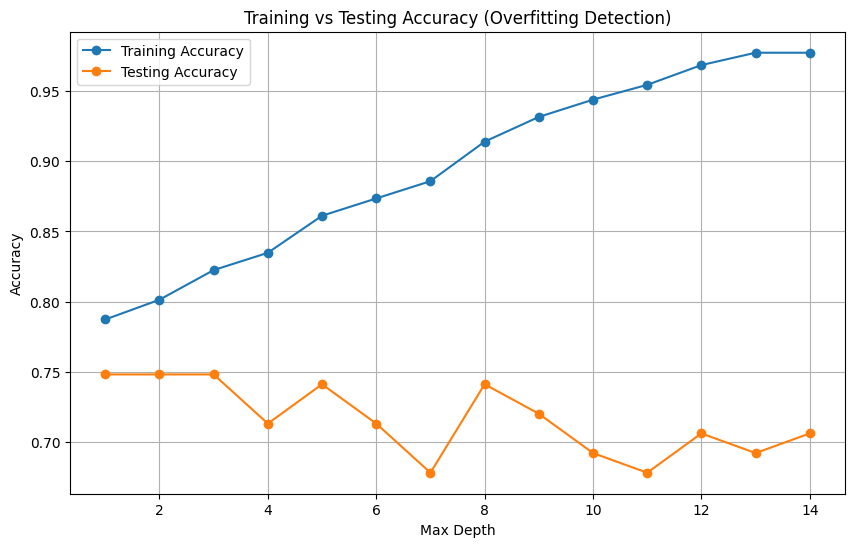

In [3]:
# Task 6: Model Tuning 

# Step 1: Imports
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Step 2: Loading and preprocessing Titanic dataset
df = sns.load_dataset("titanic")
df = df.dropna(subset=["age", "embarked", "sex", "fare", "survived"])

# Encoding categorical variables
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["embarked"] = df["embarked"].map({"S": 0, "C": 1, "Q": 2})

# Selecting features and target
X = df[["pclass", "sex", "age", "fare", "embarked"]]
y = df["survived"]

# Step 3: Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Tuning max_depth and plot training vs testing accuracy
train_acc = []
test_acc = []
depth_range = range(1, 15)

for depth in depth_range:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

# Step 5: Plotting
plt.figure(figsize=(10, 6))
plt.plot(depth_range, train_acc, label='Training Accuracy', marker='o')
plt.plot(depth_range, test_acc, label='Testing Accuracy', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy (Overfitting Detection)')
plt.legend()
plt.grid(True)
plt.show()


Part-III: Ensemble Learning – Bagging, Boosting, Random Forest Assignment


Task 7: Conceptual Questions 

1. What is the difference between Bagging and Boosting?

Ans 1.Bagging builds multiple independent models in parallel using random subsets of data to reduce variance.It aims to improve stability.

Boosting builds models sequentially, where each new model focuses on correcting errors of the previous ones, reducing bias.It aims to improve accuracy by combining weak learners.

2. How does Random Forest reduce variance? 

Ans 2.Random Forest reduces variance by building many decision trees on different random subsets of the data and features, then averaging their predictions. This diversity among trees prevents overfitting to noise in any single tree, leading to more stable and accurate overall results.


3. What is the weakness of boosting-based methods?

Ans 3.The main weakness of boosting-based methods is their sensitivity to noisy data and outliers, as they focus heavily on hard-to-classify samples, which can lead to overfitting. Additionally, boosting can be computationally intensive due to its sequential training process.



Task 8: Random Forest vs Decision Tree 

● Train a RandomForestClassifier on the same dataset used for Task 5. 

● Compare accuracy, precision, and recall with the standalone decision tree. 

● Plot feature importances. 


 Decision Tree Performance:
Accuracy : 0.713
Precision: 0.677
Recall   : 0.667

 Random Forest Performance:
Accuracy : 0.776
Precision: 0.763
Recall   : 0.714


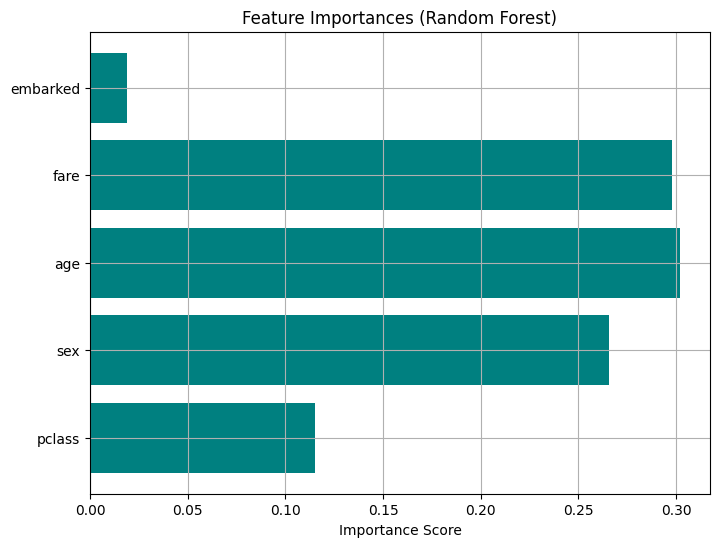

In [4]:
# Task 8: Random Forest vs Decision Tree 

# Step 1: Imports
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# Step 2: Loading and preprocessing Titanic dataset
df = sns.load_dataset("titanic")
df = df.dropna(subset=["age", "embarked", "sex", "fare", "survived"])

df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["embarked"] = df["embarked"].map({"S": 0, "C": 1, "Q": 2})

X = df[["pclass", "sex", "age", "fare", "embarked"]]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Training Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Step 4: Training Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 5: Comparing Metrics
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f"\n {name} Performance:")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")

evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)

# Step 6: Featuring Importance Plot (Random Forest)
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 6))
plt.barh(features, importances, color='teal')
plt.xlabel("Importance Score")
plt.title("Feature Importances (Random Forest)")
plt.grid(True)
plt.show()



Task 9: AdaBoost or Gradient Boosting

● Train an AdaBoostClassifier or GradientBoostingClassifier. 

● Use a suitable dataset. 

● Compare it with Random Forest and Decision Tree in terms of: 

○ Accuracy 
○ F1-score 
○ Training time (optional)

In [5]:
# Task 9: AdaBoost or Gradient Boosting

# Step 1: Imports
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# Step 2: Loading and preprocessing Titanic dataset
df = sns.load_dataset("titanic")
df = df.dropna(subset=["age", "embarked", "sex", "fare", "survived"])
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["embarked"] = df["embarked"].map({"S": 0, "C": 1, "Q": 2})

X = df[["pclass", "sex", "age", "fare", "embarked"]]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initializing models
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)

# Step 4: Fitting models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
ada.fit(X_train, y_train)

# Step 5: Evaluating models
def evaluate_booster(name, model):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"\n{name} Performance:")
    print(f"Accuracy : {acc:.3f}")
    print(f"F1-Score : {f1:.3f}")

evaluate_booster("Decision Tree", dt)
evaluate_booster("Random Forest", rf)
evaluate_booster("AdaBoost", ada)



Decision Tree Performance:
Accuracy : 0.713
F1-Score : 0.672

Random Forest Performance:
Accuracy : 0.776
F1-Score : 0.738

AdaBoost Performance:
Accuracy : 0.818
F1-Score : 0.772
